In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.metrics import DetCurveDisplay, RocCurveDisplay
import matplotlib.pyplot as plt
import math
import scipy as sp
import sys
import torch
sys.path.append('../')
import scipy.io as sio
import mat73
import pandas as pd
import numpy as np
from alive_progress import alive_bar
from utils.my_classes import dataset 
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report,accuracy_score
from sklearn.model_selection import PredefinedSplit
from sklearn.model_selection import  GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import pickle
import utils.my_classes as my_classes
import utils.my_functions as my_functions
import utils
from sklearn.metrics import roc_auc_score
from utils.my_functions import timing
import sklearn.metrics
from my_conf_inter import evaluate_with_conf_int
# Percentage for the confidence interval
alpha = 5 

# Number of bootstrap samples to use (the run time will be proportional to this number). We set it to
# 50/alpha*100 to get enough samples in the tails.
num_bootstraps = int(50/alpha*100)

print(" Number of bootstraps: ", num_bootstraps)
print(" Alpha: ", alpha)

def metric(labels, scores):
    pred = (scores > 0.5).astype(int)
    cm = confusion_matrix(labels, pred,normalize='true')
    return [100*cm[0][1], 100*cm[1][0]]

def check_performance(file_path_model,model_name,test_dataset,number_after_point = 6):
   
    with open(file_path_model, 'rb') as file:
        model = pickle.load(file)
        
        pred = model.predict(test_dataset.data)

        pos_pred_proba  = model.predict_proba(test_dataset.data)[:,1]

        #cm = confusion_matrix(test_dataset.sex, pred, labels=model.classes_,normalize=None)

        #formatted_cm = np.round(cm, decimals=number_after_point)

        # print confusion matrix - XGB
        #disp = ConfusionMatrixDisplay(confusion_matrix=formatted_cm,
        #                                display_labels=["Female","Male"])
        #disp.plot()
        plt.show()
        cm = confusion_matrix(test_dataset.sex, pred, labels=model.classes_,normalize='true')
        
        print(f"Test - {model_name} Classifier:  \n Female -> Male: {100*cm[0][1]:.3f}% , \n Male -> Female: {100*cm[1][0]:.3f}%")
        
        formatted_cm = np.round(cm, decimals=number_after_point)

        # print confusion matrix - XGB
        disp = ConfusionMatrixDisplay(confusion_matrix=formatted_cm,
                                        display_labels=["Female","Male"])
        disp.plot()
        plt.show()
        #print ROC curve - XGB
        # fpr, tpr, _ = metrics.roc_curve(test_dataset.sex, pos_pred_proba) 
        # auc = metrics.roc_auc_score(test_dataset.sex, pos_pred_proba)

        # #create ROC curve - XGB
        # plt.figure()
        # plt.plot(fpr,tpr,label=f"AUC={auc:.3f}")
        # plt.ylabel('True Positive Rate')
        # plt.xlabel('False Positive Rate')
        # plt.legend(loc=4)
        # plt.show()
        res = evaluate_with_conf_int(samples = pos_pred_proba, metric = metric, labels = test_dataset.sex, conditions = test_dataset.speaker_id, num_bootstraps=num_bootstraps, alpha=alpha)
        print(f"results : \n {res}")

        print("Test = Accuracy:",accuracy_score(test_dataset.sex, pred))
        print("Test - AUC:",roc_auc_score(test_dataset.sex,pos_pred_proba))
        print("Test - Balanced Accuracy:",metrics.balanced_accuracy_score(test_dataset.sex, pred))
        
        wrong_preds = np.array([1 if pred_element == label else 0 for pred_element, label in zip(pred, test_dataset.sex) ])
        print(f"All - {model_name} Classifier - wrong predictions:")
        print("------------------------")
        print(test_dataset.attack_logical[wrong_preds == 0].value_counts()) #wrong prediction by attack type
        print("------------------------")
        print(test_dataset.attack_logical[wrong_preds == 1].value_counts()) #correct prediction by attack type
        print("------------------------")

        # ## wrong predection by attacks with precents:
        # wrong_pred_precent = []
        # indexex_attacks = []
        # for index_attack in test_dataset.attack_logical[wrong_preds == 0].unique():  
        #     indexex_attacks.append(index_attack)
        #     wrong_pred_precent.append(test_dataset.attack_logical[wrong_preds == 0].value_counts()[index_attack]/test_dataset.attack_logical.value_counts()[index_attack])
        
        # if wrong_pred_precent != []:
        #     sorted_lists = sorted(zip(wrong_pred_precent,indexex_attacks),reverse = True)
        #     sorted_list1, sorted_list2 = zip(*sorted_lists)

        #     for i in range(len(sorted_list1)): 
        #         print(f"wrong predictions by attack type:{sorted_list2[i]} - {sorted_list1[i]:.3f}% from total {sorted_list2[i]} values") 
        # else:
        #     print("No wrong predictions")

 Number of bootstraps:  1000
 Alpha:  5


In [2]:
from ASV_utils.data_loading import *

models_folder = "ECAPA_TDNN/inference_models/"

data_path_all = "Data/male_vs_female_DB_models/16_bits/none/all/"



embedded_groups_1_1,embedded_groups_1_2,embedded_groups_1_3,chosen_labels_1_1_is_spoofed,chosen_labels_2_1_is_spoofed,chosen_labels_3_1_is_spoofed,chosen_labels_numeric_1_1,chosen_labels_numeric_2_1,chosen_labels_numeric_3_1,chosen_labels_1_1_attack_logical,chosen_labels_2_1_attack_logical,chosen_labels_3_1_attack_logical,chosen_labels_1_1_name,chosen_labels_2_1_name,chosen_labels_3_1_name,chosen_labels_1_1_speaker_id,chosen_labels_2_1_speaker_id,chosen_labels_3_1_speaker_id,chosen_labels_1_1_sex,chosen_labels_2_1_sex,chosen_labels_3_1_sex  = load_data_all(data_path_all)



In [3]:
import utils.my_functions as my_functions
columns_names,max_name_length = my_functions.get_columns_names_feature_importance(substruct=True)
true_channels_indexes = np.array(my_functions.get_real_channel(np.linspace(start=1, stop=len(columns_names), num=len(columns_names)),len(columns_names)))
true_channels_indexes = true_channels_indexes - 1
true_channels_indexes = true_channels_indexes.astype(int)
columns_names = np.array(columns_names)


embedded_groups_1_1 = embedded_groups_1_1[:,true_channels_indexes]
embedded_groups_1_2 = embedded_groups_1_2[:,true_channels_indexes]
embedded_groups_1_3 = embedded_groups_1_3[:,true_channels_indexes]

In [4]:
from sklearn.preprocessing import StandardScaler
import re

your_list = columns_names[true_channels_indexes]
index_mapping ={}

# Define the custom sorting order for distance metrics
distance_metrics = [
    'Chi-square',
    'Correlation',
    'Hellinger',
    'Intersection',
    'Jensen-Shannon',
    'Kullback-Leibler Divergence',
    'Modified Kolmogorov-Smirnov',
    'Symmetrised Kullback-Leibler'
]

def custom_sort_key(item):
    # Use regex to extract filter type, channel number, and distance metric
    match = re.search(r'filter-(gammatone|gammtone_inv)-channel-(\d+)-distance-(.+?)-\[d_', item)
    if match:
        filter_type = match.group(1)  # 'gammatone' or 'gammtone_inv'
        channel = int(match.group(2))
        distance_metric = match.group(3)
        
        # Prioritize 'gammatone' before 'gammtone_inv'
        filter_priority = 0 if filter_type == 'gammatone' else 1

        # Sort by filter type, then by distance metric, and finally by channel
        return (filter_priority, distance_metrics.index(distance_metric), channel)

    else:
        # If the regex doesn't match, push the item to the end
        return (999, 999, 999)

# Sort the list based on the custom order
sorted_list = sorted(your_list, key=custom_sort_key)

for new_index, item in enumerate(sorted_list):
    old_index = np.where(columns_names[true_channels_indexes] == item)[0][0]
    index_mapping[old_index] = new_index
    
embedded_groups_1_1 = embedded_groups_1_1[:,list(index_mapping.keys())]
embedded_groups_1_2 = embedded_groups_1_2[:,list(index_mapping.keys())]
embedded_groups_1_3 = embedded_groups_1_3[:,list(index_mapping.keys())]


In [5]:
train_dataset = dataset(data = embedded_groups_1_1 , is_spoofed = chosen_labels_1_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_1_1, # define the train set
                        attack_logical = chosen_labels_1_1_attack_logical, name = chosen_labels_1_1_name , speaker_id = chosen_labels_1_1_speaker_id, sex = chosen_labels_1_1_sex ,data_transform = None , labels_transform = None);

validation_dataset = dataset(data = embedded_groups_1_2 , is_spoofed = chosen_labels_2_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_2_1, # define the validation set
                        attack_logical = chosen_labels_2_1_attack_logical, name = chosen_labels_2_1_name , speaker_id = chosen_labels_2_1_speaker_id, sex = chosen_labels_2_1_sex ,data_transform = None , labels_transform = None);

test_dataset = dataset(data = embedded_groups_1_3 , is_spoofed = chosen_labels_3_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_3_1, # define the test set
                        attack_logical = chosen_labels_3_1_attack_logical, name = chosen_labels_3_1_name , speaker_id = chosen_labels_3_1_speaker_id,  sex = chosen_labels_3_1_sex ,data_transform = None , labels_transform = None);

In [6]:
scaler = StandardScaler(with_mean = True, with_std = True)
scaler.fit(train_dataset.data)
mean_features = scaler.mean_
std_features = scaler.scale_
train_dataset.data = scaler.transform(train_dataset.data)
validation_dataset.data = scaler.transform(validation_dataset.data)
test_dataset.data = scaler.transform(test_dataset.data)


In [7]:
train_dataset.attack_logical = pd.Series([elem[0] for elem in train_dataset.attack_logical])
validation_dataset.attack_logical = pd.Series([elem[0] for elem in validation_dataset.attack_logical])
test_dataset.attack_logical = pd.Series([elem[0] for elem in test_dataset.attack_logical])

In [8]:
train_dataset.sex[train_dataset.sex == 'male'] = 1
train_dataset.sex[train_dataset.sex == 'female'] = 0

validation_dataset.sex[validation_dataset.sex == 'male'] = 1
validation_dataset.sex[validation_dataset.sex == 'female'] = 0

test_dataset.sex[test_dataset.sex == 'male'] = 1
test_dataset.sex[test_dataset.sex == 'female'] = 0


train_dataset.sex = train_dataset.sex.astype('int')
validation_dataset.sex = validation_dataset.sex.astype('int')
test_dataset.sex = test_dataset.sex.astype('int')

## Performance on Development Set

In [9]:
models_path = "./ML_codes/pmf_both_classification_male_vs_female/new_female_and_male/female_vs_male_histograms/normalize_all_best_fixed_order/"

Test - Balanced Random Forest Classifier:  
 Female -> Male: 0.133% , 
 Male -> Female: 0.000%


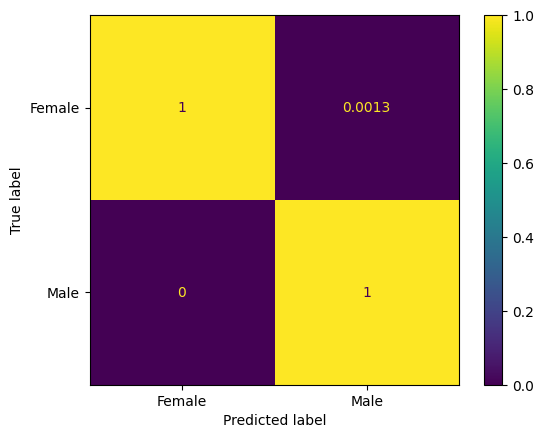

results : 
 ([0.1326579835986493, 0.0], [(0.0, 0.458195420862113), (0.0, 0.0)])
Test = Accuracy: 0.9991144743197553
Test - AUC: 0.9999989086303903
Test - Balanced Accuracy: 0.9993367100820068
All - Balanced Random Forest Classifier - wrong predictions:
------------------------
A04     11
A03      5
none     3
A05      2
A06      1
Name: count, dtype: int64
------------------------
A01     3716
A02     3716
A06     3715
A05     3714
A03     3711
A04     3705
none    2545
Name: count, dtype: int64
------------------------


In [10]:
check_performance(models_path+"gender_BRF_model_both_norm_male_vs_female_db_models_5_fixed_order.pkl","Balanced Random Forest",validation_dataset)

Test - KNN Classifier:  
 Female -> Male: 0.000% , 
 Male -> Female: 0.085%


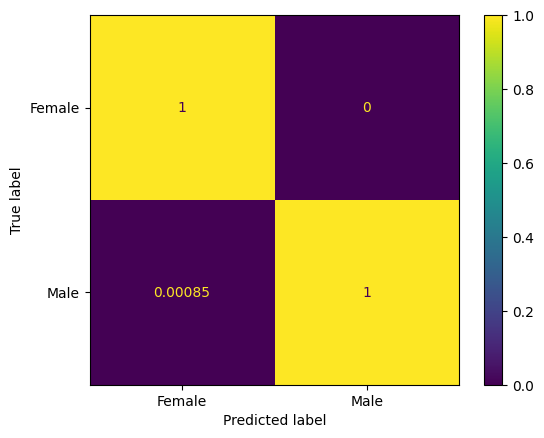

results : 
 ([0.0, 0.0847457627118644], [(0.0, 0.0), (0.0, 0.2334267040149393)])
Test = Accuracy: 0.999718241829013
Test - AUC: 0.9999993101376046
Test - Balanced Accuracy: 0.9995762711864407
All - KNN Classifier - wrong predictions:
------------------------
none    3
A05     3
A01     1
Name: count, dtype: int64
------------------------
A02     3716
A03     3716
A04     3716
A06     3716
A01     3715
A05     3713
none    2545
Name: count, dtype: int64
------------------------


In [11]:
check_performance(models_path+"gender_knn_model_both_norm_male_vs_female_db_models_5_fixed_order.pkl","KNN",validation_dataset)


Test - Logistic Regression Classifier:  
 Female -> Male: 0.030% , 
 Male -> Female: 0.036%


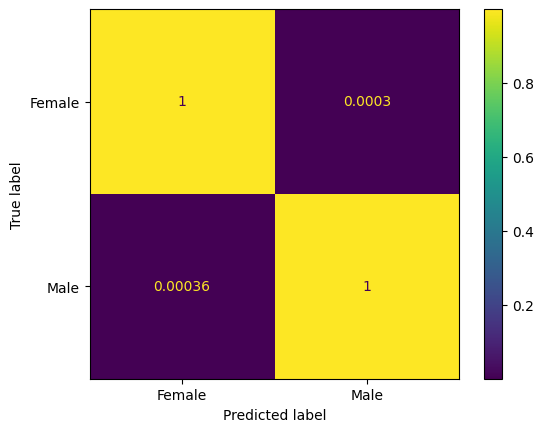

results : 
 ([0.03014954172696575, 0.03631961259079903], [(0.0, 0.13027598045939814), (0.0, 0.14530573968959629)])
Test = Accuracy: 0.9996779906617292
Test - AUC: 0.9999994086893753
Test - Balanced Accuracy: 0.9996676542284112
All - Logistic Regression Classifier - wrong predictions:
------------------------
A04     4
none    2
A05     2
Name: count, dtype: int64
------------------------
A01     3716
A02     3716
A03     3716
A06     3716
A05     3714
A04     3712
none    2546
Name: count, dtype: int64
------------------------


In [12]:
check_performance(models_path+"gender_lr_model_both_norm_male_vs_female_db_models_5_fixed_order.pkl","Logistic Regression",validation_dataset)


Test - Random Forest Classifier:  
 Female -> Male: 0.006% , 
 Male -> Female: 0.012%


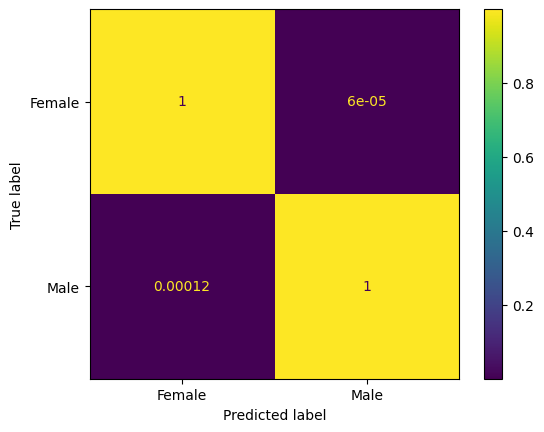

results : 
 ([0.00602990834539315, 0.012106537530266344], [(0.0, 0.03645643456069996), (0.0, 0.06381564353430155)])
Test = Accuracy: 0.9999194976654323
Test - AUC: 0.999999974449541
Test - Balanced Accuracy: 0.9999093177706218
All - Random Forest Classifier - wrong predictions:
------------------------
none    1
A04     1
Name: count, dtype: int64
------------------------
A01     3716
A02     3716
A03     3716
A05     3716
A06     3716
A04     3715
none    2547
Name: count, dtype: int64
------------------------


In [13]:
check_performance(models_path+"gender_RFC_model_both_norm_male_vs_female_db_models_5_fixed_order.pkl","Random Forest",validation_dataset)


Test - XGB Classifier:  
 Female -> Male: 0.000% , 
 Male -> Female: 0.000%


c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\xgboost\core.py:160: UserWarning: [22:03:47] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\common/error_msg.h:80: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  warnings.warn(smsg, UserWarning)


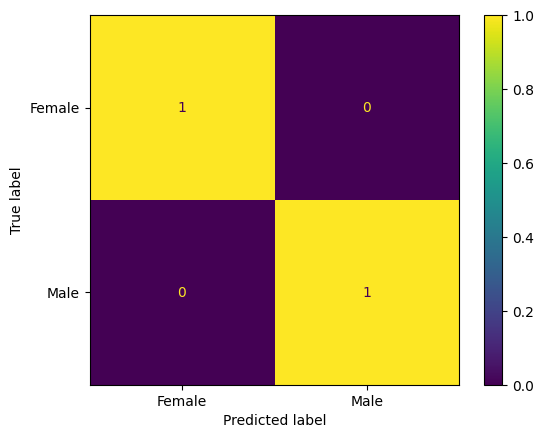

results : 
 ([0.0, 0.0], [(0.0, 0.0), (0.0, 0.0)])
Test = Accuracy: 1.0
Test - AUC: 1.0
Test - Balanced Accuracy: 1.0
All - XGB Classifier - wrong predictions:
------------------------
Series([], Name: count, dtype: int64)
------------------------
A01     3716
A02     3716
A03     3716
A04     3716
A05     3716
A06     3716
none    2548
Name: count, dtype: int64
------------------------


In [14]:
check_performance(models_path+"gender_XGB_model_both_norm_male_vs_female_db_models_5_fixed_order.pkl","XGB",validation_dataset)

Test - RUSBoost Classifier:  
 Female -> Male: 0.000% , 
 Male -> Female: 0.000%


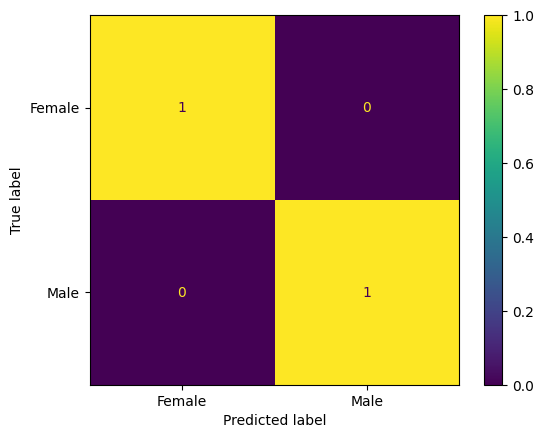

results : 
 ([0.0, 0.0], [(0.0, 0.0), (0.0, 0.0)])
Test = Accuracy: 1.0
Test - AUC: 1.0
Test - Balanced Accuracy: 1.0
All - RUSBoost Classifier - wrong predictions:
------------------------
Series([], Name: count, dtype: int64)
------------------------
A01     3716
A02     3716
A03     3716
A04     3716
A05     3716
A06     3716
none    2548
Name: count, dtype: int64
------------------------


In [15]:
check_performance(models_path+"gender_RUSBoost_model_both_norm_male_vs_female_order.pkl","RUSBoost",validation_dataset)

## Performance on Evaluation Set

Test - Balanced Random Forest Classifier:  
 Female -> Male: 2.160% , 
 Male -> Female: 1.600%


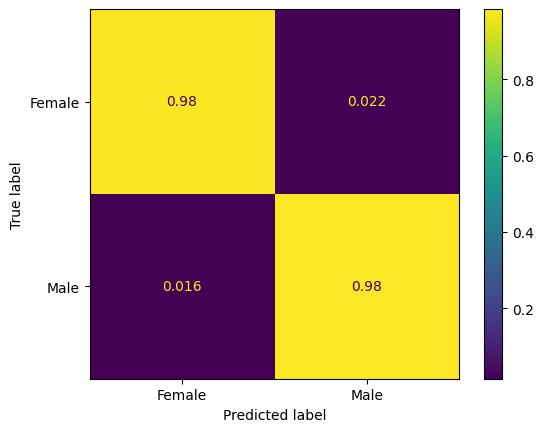

results : 
 ([2.1603310479126945, 1.5998906057705455], [(0.664352531851063, 4.230080084884717), (1.0585779435074145, 2.247828198072825)])
Test = Accuracy: 0.9801226890520376
Test - AUC: 0.9966208279962419
Test - Balanced Accuracy: 0.9811988917315838
All - Balanced Random Forest Classifier - wrong predictions:
------------------------
A19     241
A18     218
A17     191
A13     171
A14     116
A09     101
A11      80
none     79
A10      63
A08      63
A12      37
A16      30
A15      15
A07      11
Name: count, dtype: int64
------------------------
none    7276
A07     4903
A15     4899
A16     4884
A12     4877
A08     4851
A10     4851
A11     4834
A09     4813
A14     4798
A13     4743
A17     4723
A18     4696
A19     4673
Name: count, dtype: int64
------------------------


In [16]:
check_performance(models_path+"gender_BRF_model_both_norm_male_vs_female_db_models_5_fixed_order.pkl","Balanced Random Forest",test_dataset)

Test - KNN Classifier:  
 Female -> Male: 2.501% , 
 Male -> Female: 4.111%


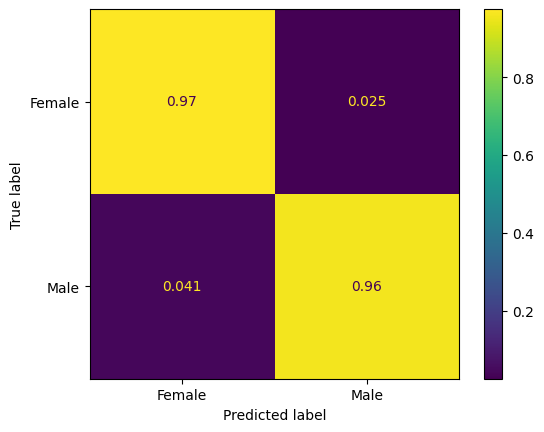

results : 
 ([2.5011156639214573, 4.111399790327727], [(1.0033383910001705, 4.67098179278387), (2.720709779650368, 5.931489662471702)])
Test = Accuracy: 0.9700296194393363
Test - AUC: 0.9807905472435529
Test - Balanced Accuracy: 0.966937422728754
All - KNN Classifier - wrong predictions:
------------------------
A13     383
A19     307
A18     243
A11     210
A17     191
A10     171
none    139
A12     104
A14     102
A08     102
A16      59
A09      57
A15      45
A07      22
Name: count, dtype: int64
------------------------
none    7216
A07     4892
A15     4869
A09     4857
A16     4855
A14     4812
A08     4812
A12     4810
A10     4743
A17     4723
A11     4704
A18     4671
A19     4607
A13     4531
Name: count, dtype: int64
------------------------


In [17]:
check_performance(models_path+"gender_knn_model_both_norm_male_vs_female_db_models_5_fixed_order.pkl","KNN",test_dataset)

Test - Logistic Regression Classifier:  
 Female -> Male: 1.696% , 
 Male -> Female: 1.377%


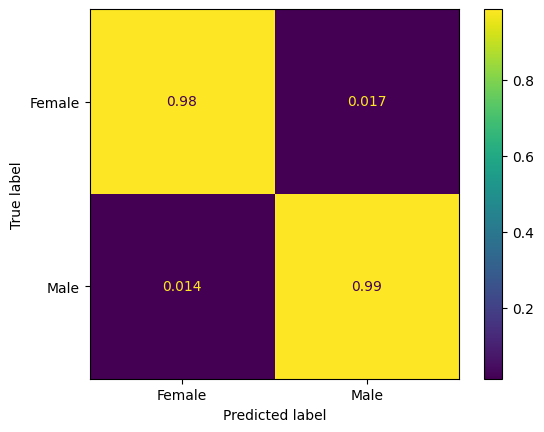

results : 
 ([1.695809160615035, 1.3765440539678198], [(0.7062400570592564, 3.2101583645445575), (0.32358754161493264, 2.9612905500820554)])
Test = Accuracy: 0.9840251554669623
Test - AUC: 0.9988053031229689
Test - Balanced Accuracy: 0.9846382339270857
All - Logistic Regression Classifier - wrong predictions:
------------------------
A18     318
A19     163
A14     137
A17      99
A08      89
A12      68
none     60
A13      45
A16      40
A09      34
A10      32
A07      30
A11      12
A15      11
Name: count, dtype: int64
------------------------
none    7295
A15     4903
A11     4902
A07     4884
A10     4882
A09     4880
A16     4874
A13     4869
A12     4846
A08     4825
A17     4815
A14     4777
A19     4751
A18     4596
Name: count, dtype: int64
------------------------


In [18]:
check_performance(models_path+"gender_lr_model_both_norm_male_vs_female_db_models_5_fixed_order.pkl","Logistic Regression",test_dataset)

Test - Random Forest Classifier:  
 Female -> Male: 2.108% , 
 Male -> Female: 1.933%


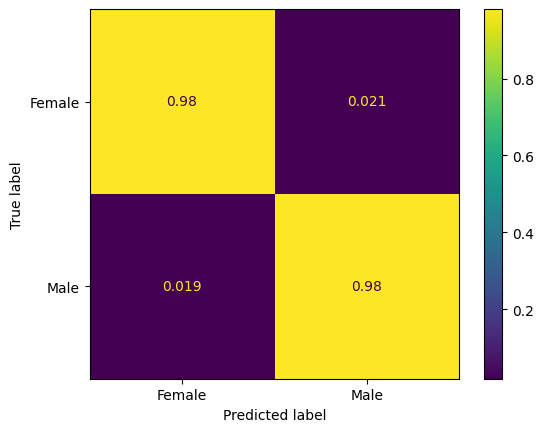

results : 
 ([2.107590571625624, 1.9326313870276675], [(0.5922229595760531, 4.123220192382374), (1.2455967674089143, 2.8099833038184063)])
Test = Accuracy: 0.9794629195502337
Test - AUC: 0.9967083718944683
Test - Balanced Accuracy: 0.9797988902067335
All - Random Forest Classifier - wrong predictions:
------------------------
A19     218
A18     209
A13     208
A17     187
A14     144
A09     111
A11      77
none     73
A10      71
A08      66
A12      39
A16      25
A15      24
A07      11
Name: count, dtype: int64
------------------------
none    7282
A07     4903
A15     4890
A16     4889
A12     4875
A08     4848
A10     4843
A11     4837
A09     4803
A14     4770
A17     4727
A13     4706
A18     4705
A19     4696
Name: count, dtype: int64
------------------------


In [19]:
check_performance(models_path+"gender_RFC_model_both_norm_male_vs_female_db_models_5_fixed_order.pkl","Random Forest",test_dataset)

Test - XGB Classifier:  
 Female -> Male: 1.799% , 
 Male -> Female: 0.944%


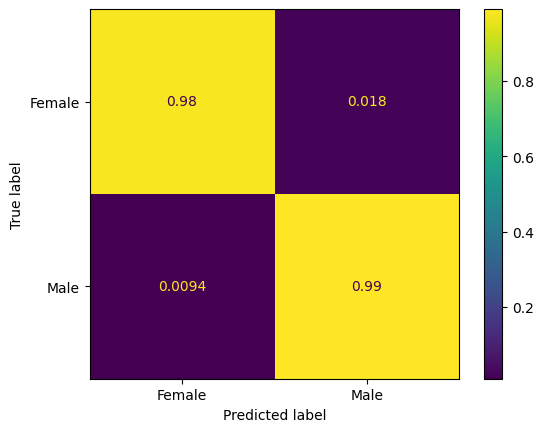

results : 
 ([1.7992616333319809, 0.9435252290441679], [(0.6425054521456774, 3.294711679570885), (0.3762349769890261, 1.689857727897401)])
Test = Accuracy: 0.9846428120218426
Test - AUC: 0.998821985680088
Test - Balanced Accuracy: 0.9862860656881192
All - XGB Classifier - wrong predictions:
------------------------
A18     286
A19     172
A13     135
A14     131
A08      87
A17      69
A09      51
A12      35
none     33
A16      28
A10      28
A11      18
A15      15
A07       6
Name: count, dtype: int64
------------------------
none    7322
A07     4908
A15     4899
A11     4896
A16     4886
A10     4886
A12     4879
A09     4863
A17     4845
A08     4827
A14     4783
A13     4779
A19     4742
A18     4628
Name: count, dtype: int64
------------------------


In [20]:
check_performance(models_path+"gender_XGB_model_both_norm_male_vs_female_db_models_5_fixed_order.pkl","XGB",test_dataset)

Test - RUSBoost Classifier:  
 Female -> Male: 1.931% , 
 Male -> Female: 1.026%


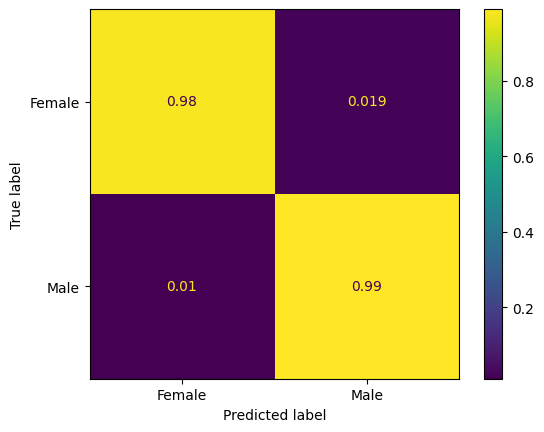

results : 
 ([1.9311128240496571, 1.0255709011349652], [(0.7577238925128611, 3.521182677516703), (0.3066372434639202, 2.092556237484764)])
Test = Accuracy: 0.9834776871569549
Test - AUC: 0.9988303662541458
Test - Balanced Accuracy: 0.985216581374077
All - RUSBoost Classifier - wrong predictions:
------------------------
A18     354
A19     173
A14     164
A13     125
A08      97
A17      67
A09      55
A12      30
none     29
A16      25
A15      24
A10      16
A11      15
A07       3
Name: count, dtype: int64
------------------------
none    7326
A07     4911
A11     4899
A10     4898
A15     4890
A16     4889
A12     4884
A09     4859
A17     4847
A08     4817
A13     4789
A14     4750
A19     4741
A18     4560
Name: count, dtype: int64
------------------------


In [21]:
check_performance(models_path+"gender_RUSBoost_model_both_norm_male_vs_female_order.pkl","RUSBoost",test_dataset)